In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp
# из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# первых производных в (8.111)
def Oscillator(t, z):
    # инициализация массива, используемого для
    # хранения значений первых производных
    dy = np.zeros(2)

    dy[0] = z[1]
    dy[1] = a / L * Gg**2 * np.cos(z[0] - Gg * t) - g / L * np.sin(z[0])

    return dy

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат узлов ВС,
# использованной для вычисления
# численного решения СДУ (8.111)
# x=x(t), y=y(t)
def Solv_ODE(phi0, dphi_dt0, Tmax, t):
    # вычисление численного решения СДУ (8.67)
    # в узлах ВС, координаты которых
    # размещены в массиве t
    Solv = solve_ivp(
        Oscillator,
        [0, Tmax],
        [phi0, dphi_dt0],
        t_eval=t,
        method="RK45",
        rtol=1e-8,
        atol=1e-8,
    )

    # размещение значений координат узлов
    # временной сетки, на которой найдены численные решения
    # системы ОДУ (8.67) в массив t
    t = Solv.t

    # размещение мгновенных значений
    # угла отклонения математического маятника
    # от вертикали в массив phi
    phi = Solv.y[0, :]

    # размещение мгновенных значений
    # угловой скорости математического маятника
    # составляющей скорости в массив dphi_dt
    dphi_dt = Solv.y[1, :]

    return phi, dphi_dt

In [4]:
# Ячейка № 4

# задание функции, возвращающей
# значения декартовых координат
# маятника с колеблющейся точкой подвеса
def Coordinates(phi):
    # определение числа узлов временной сетки
    Np1 = len(phi)

    # инициализация массивов, используемых
    # для хранения мгновенных значений
    # декартовых координат и энергии математического маятника.
    x1 = np.zeros(Np1)
    y1 = np.zeros(Np1)

    # вычисление декартовых координат
    # математического маятника
    for i in range(Np1):
        # Квадрант I
        if (phi[i] >= 0) & (phi[i] >= np.pi / 2):
            x1[i] = L * np.sin(np.pi - phi[i])
            y1[i] = L * np.cos(np.pi - phi[i])
        # Квадрант II
        if (phi[i] < 0) & (np.abs(phi[i]) >= np.pi / 2):
            x1[i] = -L * np.sin(np.pi - np.abs(phi[i]))
            y1[i] = L * np.cos(np.pi - np.abs(phi[i]))
        # Квадрант III
        if (phi[i] < 0) & (np.abs(phi[i]) < np.pi / 2):
            x1[i] = -L * np.sin(np.abs(phi[i]))
            y1[i] = -L * np.cos(np.abs(phi[i]))
        # Квадрант IV
        if (phi[i] > 0) & (phi[i] <= np.pi / 2):
            x1[i] = L * np.sin(phi[i])
            y1[i] = -L * np.cos(phi[i])
        x1[i] = a * np.cos(Gg * t[i]) + x1[i]
        y1[i] = -a * np.sin(Gg * t[i]) + y1[i]

    return x1, y1

In [5]:
# Ячейка № 5

# задание значения
# ускорения свободного падения
g = 9.8

# задание длины маятника
L = 0.5

# задаем амплитуду колебаний точки подвеса
a = 0.1

# задаем частоту колебаний точки подвеса
Gg = 5

# задание начального угла отклонения
# математического маятника от вертикали
phi0_1 = np.pi * 0.1

# задание начального значения скорости
# математического маятника
dphi_dt0 = 0

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (8.111)
N = 10**4
Tmax = 10

dt = Tmax / N

# задание ВС, в узлах которой
# вычисляется численное решение СДУ (8.111)
t = np.linspace(0, Tmax, N)

# вычисление численного решения СДУ (8.111)
phi_1, dphi_dt1 = Solv_ODE(phi0_1, dphi_dt0, Tmax, t)

# вычисление координат маятника
# с учетом номера квадранта,
# в находится маятник
x1, y1 = Coordinates(phi_1)

# задание начального угла отклонения
# математического маятника от вертикали
phi0_2 = np.pi * 0.9

# вычисление численного решения СДУ (8.111)
phi_2, dphi_dt2 = Solv_ODE(phi0_2, dphi_dt0, Tmax, t)

# вычисление координат маятника
# с учетом номера квадранта,
# в находится маятник
x2, y2 = Coordinates(phi_2)

# задаем частоту колебаний точки подвеса
Gg = 50

# задание начального угла отклонения
# математического маятника от вертикали
phi0_3 = np.pi * 0.1

# вычисление численного решения СДУ (8.111)
phi_3, dphi_dt3 = Solv_ODE(phi0_3, dphi_dt0, Tmax, t)

# вычисление координат маятника
# с учетом номера квадранта,
# в находится маятник
x3, y3 = Coordinates(phi_3)

# задание начального угла отклонения
# математического маятника от вертикали
phi0_4 = np.pi * 0.9

# вычисление численного решения СДУ (8.111)
phi_4, dphi_dt4 = Solv_ODE(phi0_4, dphi_dt0, Tmax, t)

# вычисление координат маятника
# с учетом номера квадранта,
# в находится маятник
x4, y4 = Coordinates(phi_4)


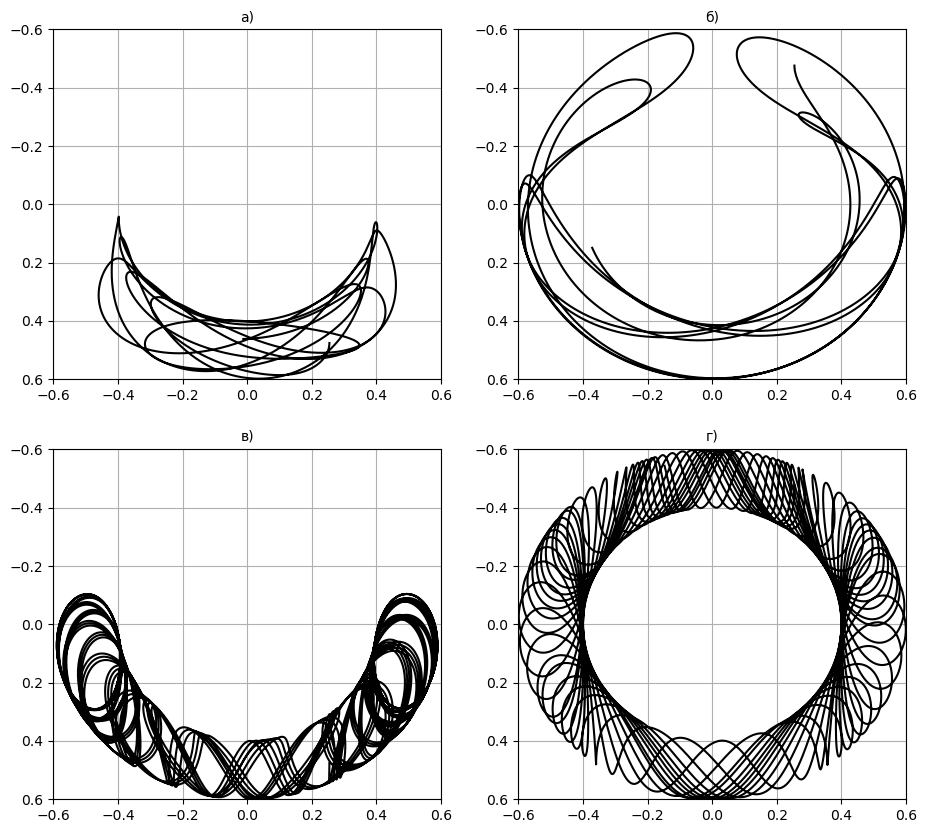

In [6]:
# Ячейка № 6

# визуализация траекторий движения маятника

fig = plt.figure(figsize=(11, 10))

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(x1, -y1, "black")
ax1.set_ylim(0.6, -0.6)
ax1.set_xlim(-0.6, 0.6)
ax1.grid(True)
ax1.set_title("а)", fontsize=10)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(x2, -y2, "black")
ax2.set_ylim(0.6, -0.6)
ax2.set_xlim(-0.6, 0.6)
ax2.grid(True)
ax2.set_title("б)", fontsize=10)

ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(x3, -y3, "black")
ax3.set_ylim(0.6, -0.6)
ax3.set_xlim(-0.6, 0.6)
ax3.grid(True)
ax3.set_title("в)", fontsize=10)

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(x4, -y4, "black")
ax4.set_ylim(0.6, -0.6)
ax4.set_xlim(-0.6, 0.6)
ax4.grid(True)
ax4.set_title("г)", fontsize=10)

plt.show()